# HR Employee Churn Analysis


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, ttest_ind

pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

## 1. Data Review and Cleaning

First, inspect the dataset structure, then standardize the values and convert the numeric columns used later in the hypothesis tests.

In [42]:
df = pd.read_csv('hr_attribution.csv')

print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('Column names:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nFirst 5 rows:')
print(df.head())
print('\nMissing values:')
missing_values = df.isna().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))
print('\nAttrition distribution (%):')
print(df['attrition'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Rows: 15000
Columns: 35
Column names:
['employee_id', 'age', 'gender', 'marital_status', 'education', 'education_field', 'num_companies_worked', 'department', 'job_role', 'job_level', 'employment_type', 'years_at_company', 'years_in_current_role', 'total_working_years', 'monthly_income', 'percent_salary_hike', 'stock_option_level', 'bonus_eligible', 'overtime_paid_eligible', 'business_travel', 'work_life_balance', 'job_satisfaction', 'environment_satisfaction', 'relationship_satisfaction', 'overtime_hours_per_week', 'performance_rating', 'training_times_last_year', 'promotions_last_5years', 'years_since_last_promotion', 'skills_growth_opportunities', 'manager_rating', 'team_size', 'distance_from_home_km', 'remote_work_days_per_week', 'attrition']

Data types:
employee_id                        str
age                              int64
gender                             str
marital_status                     str
education                          str
education_field                    

In [43]:
clean_df = df.drop_duplicates(subset=['employee_id']).copy()

for column in clean_df.select_dtypes(include='object').columns:
    clean_df[column] = clean_df[column].astype('string').str.strip()

numeric_columns = ['monthly_income', 'percent_salary_hike', 'job_satisfaction', 'environment_satisfaction', 'relationship_satisfaction', 'overtime_hours_per_week', 'performance_rating', 'training_times_last_year', 'promotions_last_5years', 'years_since_last_promotion', 'manager_rating', 'work_life_balance', 'years_at_company', 'years_in_current_role', 'total_working_years', 'distance_from_home_km', 'remote_work_days_per_week']
for column in numeric_columns:
    if column in clean_df.columns:
        clean_df[column] = pd.to_numeric(clean_df[column], errors='coerce')

print('Rows after removing duplicates:', len(clean_df))
print('Missing values after basic cleaning:')
remaining_missing = clean_df.isnull().sum()
print(remaining_missing[remaining_missing > 0].sort_values(ascending=False))

Rows after removing duplicates: 15000
Missing values after basic cleaning:
monthly_income        450
job_satisfaction      450
performance_rating    450
dtype: int64


C:\Users\MuvvaAkshaya\AppData\Local\Temp\ipykernel_3344\3008054701.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in clean_df.select_dtypes(include='object').columns:


In [44]:
analysis_df = clean_df.copy()
print('Current missing values in the analysis frame:')
print(analysis_df.isna().sum()[analysis_df.isna().sum() > 0].sort_values(ascending=False))

Current missing values in the analysis frame:
monthly_income        450
job_satisfaction      450
performance_rating    450
dtype: int64


## 2. Hypothesis

The notebook assumes the following working hypotheses before testing them. The null and alternative hypotheses are stated explicitly so the results are easy to read.

- Business travel is associated with churn.
  - H0: Business travel and attrition are independent.
  - H1: Business travel and attrition are associated.
- Job satisfaction is associated with churn.
  - H0: Mean job satisfaction is the same for employees who stayed and employees who left.
  - H1: Mean job satisfaction differs between the two attrition groups.
- Overtime hours are associated with churn.
  - H0: Mean overtime hours are the same for both attrition groups.
  - H1: Mean overtime hours differ between the two attrition groups.
- Years since last promotion is associated with churn.
  - H0: Mean years since last promotion is the same for both attrition groups.
  - H1: Mean years since last promotion differs between the two attrition groups.
- Performance rating is associated with churn.
  - H0: Mean performance rating is the same for both attrition groups.
  - H1: Mean performance rating differs between the two attrition groups.

For null handling, the notebook first checks whether a useful association exists. If the association is weak, the missing values are filled with the mode and the analysis stops there. If the association is strong enough, grouped median imputation is tried first and mode is used only as the fallback.

In [45]:
# print('Performance rating check:')
# performance_factors = ['training_times_last_year', 'promotions_last_5years', 'years_since_last_promotion', 'bonus_eligible', 'percent_salary_hike', 'manager_rating']
# performance_rows = []
# for factor in performance_factors:
#     if factor not in analysis_df.columns:
#         continue
#     pair = analysis_df[['performance_rating', factor]].dropna()
#     if len(pair) < 3:
#         continue
#     target_values = pd.to_numeric(pair['performance_rating'], errors='coerce')
#     factor_values = pair[factor]
#     if pd.api.types.is_numeric_dtype(factor_values):
#         factor_values = pd.to_numeric(factor_values, errors='coerce')
#     else:
#         factor_values = pd.Series(pd.factorize(factor_values.astype('string'))[0], index=factor_values.index).replace(-1, np.nan)
#     valid = target_values.notna() & factor_values.notna()
#     if valid.sum() < 3:
#         continue
#     corr_value = np.corrcoef(target_values[valid].to_numpy(), factor_values[valid].to_numpy())[0, 1]
#     performance_rows.append([factor, round(float(corr_value), 4)])
# performance_table = pd.DataFrame(performance_rows, columns=['factor', 'corr'])
# print(performance_table)

# print('The correlations are weak, so I am using mode for performance_rating.')
analysis_df['performance_rating'] = analysis_df['performance_rating'].fillna(analysis_df['performance_rating'].mode(dropna=True).iloc[0])
print('Performance rating missing values after mode imputation:', analysis_df['performance_rating'].isna().sum())

Performance rating missing values after mode imputation: 0


In [46]:
# print('Job satisfaction check:')
# job_satisfaction_factors = ['percent_salary_hike', 'bonus_eligible', 'overtime_paid_eligible', 'work_life_balance', 'environment_satisfaction', 'overtime_hours_per_week', 'skills_growth_opportunities']
# job_satisfaction_rows = []
# for factor in job_satisfaction_factors:
#     if factor not in analysis_df.columns:
#         continue
#     pair = analysis_df[['job_satisfaction', factor]].dropna()
#     if len(pair) < 3:
#         continue
#     target_values = pd.to_numeric(pair['job_satisfaction'], errors='coerce')
#     factor_values = pair[factor]
#     if pd.api.types.is_numeric_dtype(factor_values):
#         factor_values = pd.to_numeric(factor_values, errors='coerce')
#     else:
#         factor_values = pd.Series(pd.factorize(factor_values.astype('string'))[0], index=factor_values.index).replace(-1, np.nan)
#     valid = target_values.notna() & factor_values.notna()
#     if valid.sum() < 3:
#         continue
#     corr_value = np.corrcoef(target_values[valid].to_numpy(), factor_values[valid].to_numpy())[0, 1]
#     job_satisfaction_rows.append([factor, round(float(corr_value), 4)])
# job_satisfaction_table = pd.DataFrame(job_satisfaction_rows, columns=['factor', 'corr'])
# print(job_satisfaction_table)
# print('The correlations are weak, so I am using mode for job_satisfaction.')
analysis_df['job_satisfaction'] = analysis_df['job_satisfaction'].fillna(analysis_df['job_satisfaction'].mode(dropna=True).iloc[0])
print('Job satisfaction missing values after mode imputation:', analysis_df['job_satisfaction'].isna().sum())
print('Remaining missing values after targeted handling:')
print(analysis_df.isna().sum()[analysis_df.isna().sum() > 0].sort_values(ascending=False))

Job satisfaction missing values after mode imputation: 0
Remaining missing values after targeted handling:
monthly_income    450
dtype: int64


## 2.8 Feature Engineering

Build new features to capture key relationships and patterns. These include ratio features, binary behavior flags, and bucketized distance groups.

In [47]:
feat_df = analysis_df.copy()

analysis_df['tenure_ratio'] = analysis_df['years_in_current_role'] / (analysis_df['years_at_company'] + 1)
analysis_df['income_per_experience_year'] = analysis_df['monthly_income'] / (analysis_df['total_working_years'] + 1)

analysis_df['is_frequent_traveler'] = analysis_df['business_travel'].isin(['Travel_Frequently']).astype(int)
analysis_df['is_remote_heavy'] = (analysis_df['remote_work_days_per_week'] >= 3).astype(int)
analysis_df['is_overtime_heavy'] = (analysis_df['overtime_hours_per_week'] >= 45).astype(int)
analysis_df['is_low_satisfaction'] = (analysis_df['job_satisfaction'] <= 2).astype(int)

analysis_df['distance_bucket'] = pd.cut(
    analysis_df['distance_from_home_km'],
    bins=[-1, 5, 15, 30, np.inf],
    labels=['Very_Near', 'Near', 'Moderate', 'Far']
)

analysis_df['income_bucket'] = pd.cut(
    analysis_df['monthly_income'],
    bins=[0, 5000, 10000, 15000, np.inf],
    labels=['Low', 'Medium', 'High', 'Very_High']
)

analysis_df['years_in_role_bucket'] = pd.cut(
    analysis_df['years_in_current_role'],
    bins=[-1, 2, 5, 10, np.inf],
    labels=['New', 'Established', 'Veteran', 'Senior']
)

print('New features created:')
print('  - Ratio features: tenure_ratio, income_per_experience_year')
print('  - Binary flags: is_frequent_traveler, is_remote_heavy, is_overtime_heavy, is_low_satisfaction')
print('  - Bucketized features: distance_bucket, income_bucket, years_in_role_bucket')
print('\nFeature engineered dataset shape:', analysis_df.shape)
print('\nSample of engineered features:')
eng_features = ['employee_id', 'tenure_ratio', 'income_per_experience_year', 'is_frequent_traveler', 
                'is_remote_heavy', 'is_overtime_heavy', 'distance_bucket', 'income_bucket', 'years_in_role_bucket']
print(analysis_df[eng_features].head(10))

New features created:
  - Ratio features: tenure_ratio, income_per_experience_year
  - Binary flags: is_frequent_traveler, is_remote_heavy, is_overtime_heavy, is_low_satisfaction
  - Bucketized features: distance_bucket, income_bucket, years_in_role_bucket

Feature engineered dataset shape: (15000, 44)

Sample of engineered features:
    employee_id  tenure_ratio  income_per_experience_year  \
0  EMP_00000001      0.750000                 1972.000000   
1  EMP_00000002      0.500000                  664.857143   
2  EMP_00000003      1.500000                  163.600000   
3  EMP_00000004      3.000000                  534.400000   
4  EMP_00000005      1.000000                 1573.250000   
5  EMP_00000006      1.500000                  807.800000   
6  EMP_00000007      0.000000                  643.000000   
7  EMP_00000008      0.571429                  523.571429   
8  EMP_00000009      0.500000                  934.000000   
9  EMP_00000010      3.000000                  671.250

## 2.7 Monthly Income Imputation

After job_satisfaction and performance_rating are filled, address the remaining monthly_income nulls. Group by job_role and job_level to capture domain-specific salary patterns, then impute using the median within each group.

In [48]:
print('Monthly income imputation using job_role and job_level groups:')
income_by_group = analysis_df.groupby(['job_role', 'job_level'])['monthly_income'].median()
print('Median monthly income by job_role and job_level:')
print(income_by_group)

null_mask = analysis_df['monthly_income'].isna()
for idx in analysis_df[null_mask].index:
    job_role = analysis_df.loc[idx, 'job_role']
    job_level = analysis_df.loc[idx, 'job_level']
    group_key = (job_role, job_level)
    if group_key in income_by_group.index:
        analysis_df.loc[idx, 'monthly_income'] = income_by_group.loc[group_key]

if analysis_df['monthly_income'].isna().any():
    global_median = analysis_df['monthly_income'].median()
    analysis_df['monthly_income'] = analysis_df['monthly_income'].fillna(global_median)
    print(f'Remaining nulls filled with global median: {global_median}')

print('Monthly income missing values after group imputation:', analysis_df['monthly_income'].isna().sum())
print('Final missing values summary:')
print(analysis_df.isna().sum()[analysis_df.isna().sum() > 0].sort_values(ascending=False))

Monthly income imputation using job_role and job_level groups:
Median monthly income by job_role and job_level:
job_role   job_level
Analyst    1            3521.0
           2            3614.5
           3            3769.0
           4            3684.0
           5            4387.5
Executive  1            3650.0
           2            3411.0
           3            3752.0
           4            3460.0
           5            3652.0
Junior     1            3646.5
           2            3538.0
           3            3663.0
           4            3651.0
           5            3775.0
Manager    1            3571.0
           2            3748.0
           3            3730.0
           4            3487.0
           5            3486.5
Senior     1            3593.0
           2            3629.0
           3            3697.0
           4            3596.0
           5            3708.0
Name: monthly_income, dtype: float64
Monthly income missing values after group imputation: 0

## 2.5 Normality Check

Some numeric columns are usually right-skewed. I will check the skewness first and then apply a simple transform only where it helps.

In [49]:
from scipy.stats import skew

normality_columns = ['monthly_income', 'overtime_hours_per_week', 'years_since_last_promotion']

print('Skewness before transformation:')
for column in normality_columns:
    if column in clean_df.columns:
        print(column, round(float(skew(clean_df[column].dropna())), 4))

analysis_df['log_monthly_income'] = np.log1p(analysis_df['monthly_income'])
analysis_df['sqrt_overtime_hours'] = np.sqrt(analysis_df['overtime_hours_per_week'])
analysis_df['inverse_years_since_promotion'] = 1 / (analysis_df['years_since_last_promotion'] + 1)

print('\nSkewness after transformation:')
print('log_monthly_income', round(float(skew(analysis_df['log_monthly_income'].dropna())), 4))
print('sqrt_overtime_hours', round(float(skew(analysis_df['sqrt_overtime_hours'].dropna())), 4))
print('inverse_years_since_promotion', round(float(skew(analysis_df['inverse_years_since_promotion'].dropna())), 4))

Skewness before transformation:
monthly_income 1.7301
overtime_hours_per_week 1.984
years_since_last_promotion 1.6625

Skewness after transformation:
log_monthly_income -0.0037
sqrt_overtime_hours 0.3161
inverse_years_since_promotion 0.5542


## 3. Hypothesis Testing

Now that the null values for the key testing features are handled, test the hypotheses with explicit null and alternative statements.

In [50]:
alpha = 0.05

travel_table = pd.crosstab(analysis_df['business_travel'], analysis_df['attrition'])
chi2_stat, travel_p_value, travel_dof, travel_expected = chi2_contingency(travel_table)
print('Business travel vs attrition')
print(travel_table)
print('chi-square statistic:', round(float(chi2_stat), 4))
print('p-value:', travel_p_value)
print('Decision:', 'Reject H0' if travel_p_value < alpha else 'Fail to reject H0')

for column, label in [('job_satisfaction', 'Job satisfaction vs attrition'), ('overtime_hours_per_week', 'Overtime hours vs attrition'), ('years_since_last_promotion', 'Years since last promotion vs attrition'), ('performance_rating', 'Performance rating vs attrition')]:
    yes_values = pd.to_numeric(analysis_df.loc[analysis_df['attrition'] == 'Yes', column], errors='coerce').dropna()
    no_values = pd.to_numeric(analysis_df.loc[analysis_df['attrition'] == 'No', column], errors='coerce').dropna()
    stat, p_value = ttest_ind(yes_values, no_values, equal_var=False)
    print('\n' + label)
    print('Null hypothesis: the two attrition groups have the same mean.')
    print('Alternative hypothesis: the two attrition groups have different means.')
    print('Mean for Yes:', round(float(yes_values.mean()), 2))
    print('Mean for No:', round(float(no_values.mean()), 2))
    print('t-statistic:', round(float(stat), 4))
    print('p-value:', p_value)
    print('Decision:', 'Reject H0' if p_value < alpha else 'Fail to reject H0')

Business travel vs attrition
attrition            No   Yes
business_travel              
Non-Travel         1972  1057
Travel_Frequently  2066  1598
Travel_Rarely      5355  2952
chi-square statistic: 80.8717
p-value: 2.7475229059519283e-18
Decision: Reject H0

Job satisfaction vs attrition
Null hypothesis: the two attrition groups have the same mean.
Alternative hypothesis: the two attrition groups have different means.
Mean for Yes: 2.75
Mean for No: 3.07
t-statistic: -22.5213
p-value: 8.81102950329258e-110
Decision: Reject H0

Overtime hours vs attrition
Null hypothesis: the two attrition groups have the same mean.
Alternative hypothesis: the two attrition groups have different means.
Mean for Yes: 4.92
Mean for No: 4.37
t-statistic: 6.2073
p-value: 5.59603374350109e-10
Decision: Reject H0

Years since last promotion vs attrition
Null hypothesis: the two attrition groups have the same mean.
Alternative hypothesis: the two attrition groups have different means.
Mean for Yes: 2.89
Mea

## 4. Exploratory Data Analysis



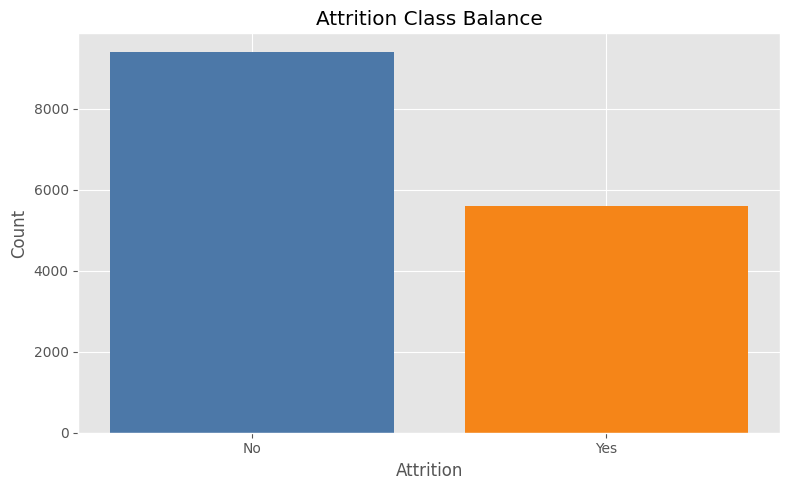

In [51]:
plt.figure(figsize=(8, 5))
attrition_counts = analysis_df['attrition'].value_counts().reindex(['No', 'Yes']).fillna(0)
plt.bar(attrition_counts.index, attrition_counts.values, color=['#4C78A8', '#F58518'])
plt.title('Attrition Class Balance')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Insight

The class balance shows whether churn is imbalanced. That matters because a model can otherwise lean too much toward the majority class.

<Figure size 900x500 with 0 Axes>

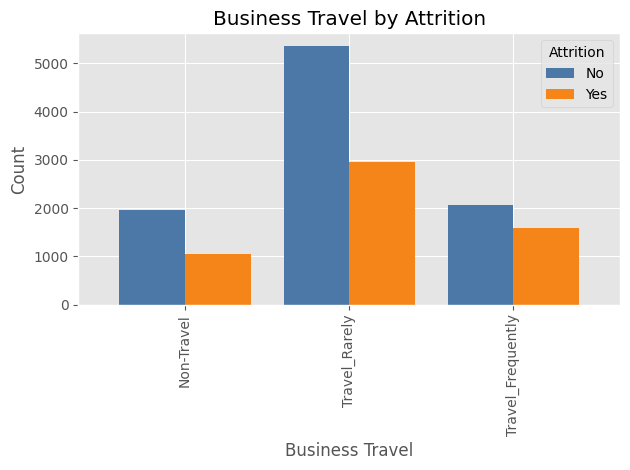

In [52]:
plt.figure(figsize=(9, 5))
travel_counts = pd.crosstab(analysis_df['business_travel'], analysis_df['attrition']).reindex(['Non-Travel', 'Travel_Rarely', 'Travel_Frequently'])
travel_counts.plot(kind='bar', color=['#4C78A8', '#F58518'], width=0.8)
plt.title('Business Travel by Attrition')
plt.xlabel('Business Travel')
plt.ylabel('Count')
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

### Insight

Frequent travel is treated as a churn risk signal here, so this graph checks whether the left group is visibly more concentrated among frequent travelers.

C:\Users\MuvvaAkshaya\AppData\Local\Temp\ipykernel_3344\2719112531.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([job_sat_no, job_sat_yes], labels=['No', 'Yes'], patch_artist=True, boxprops=dict(facecolor='#A0CBE8', color='#2F4B7C'), medianprops=dict(color='#E45756', linewidth=2))


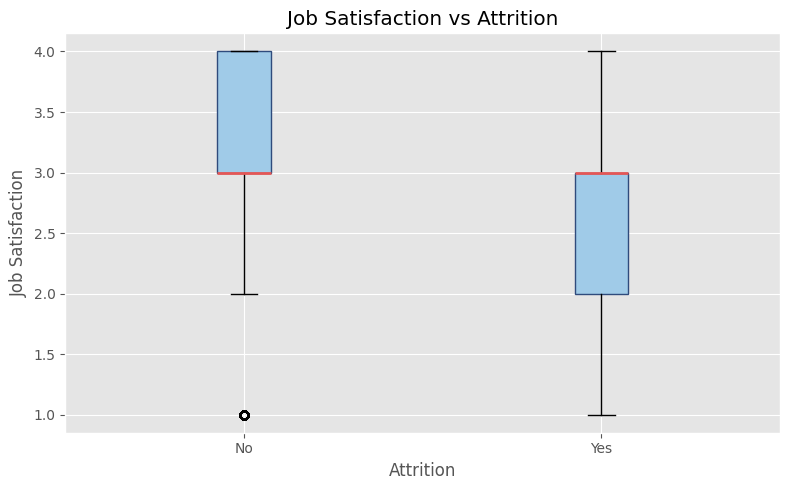

In [53]:
plt.figure(figsize=(8, 5))
job_sat_no = analysis_df.loc[analysis_df['attrition'] == 'No', 'job_satisfaction'].dropna()
job_sat_yes = analysis_df.loc[analysis_df['attrition'] == 'Yes', 'job_satisfaction'].dropna()
plt.boxplot([job_sat_no, job_sat_yes], labels=['No', 'Yes'], patch_artist=True, boxprops=dict(facecolor='#A0CBE8', color='#2F4B7C'), medianprops=dict(color='#E45756', linewidth=2))
plt.title('Job Satisfaction vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Job Satisfaction')
plt.tight_layout()
plt.show()

### Insight

Lower job satisfaction should align with churn if the hypothesis is valid.

C:\Users\MuvvaAkshaya\AppData\Local\Temp\ipykernel_3344\3580849457.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([overtime_no, overtime_yes], labels=['No', 'Yes'], patch_artist=True, boxprops=dict(facecolor='#54A24B', color='#2F4B7C'), medianprops=dict(color='#E45756', linewidth=2))


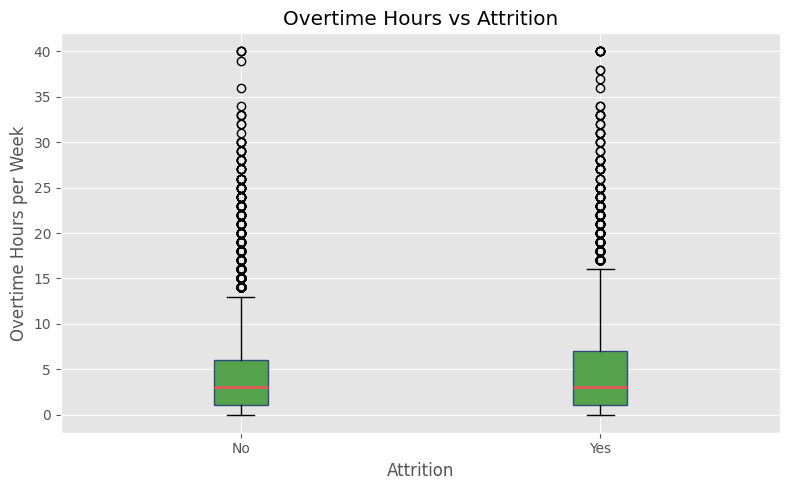

In [55]:
plt.figure(figsize=(8, 5))
overtime_no = analysis_df.loc[analysis_df['attrition'] == 'No', 'overtime_hours_per_week'].dropna()
overtime_yes = analysis_df.loc[analysis_df['attrition'] == 'Yes', 'overtime_hours_per_week'].dropna()
plt.boxplot([overtime_no, overtime_yes], labels=['No', 'Yes'], patch_artist=True, boxprops=dict(facecolor='#54A24B', color='#2F4B7C'), medianprops=dict(color='#E45756', linewidth=2))
plt.title('Overtime Hours vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Overtime Hours per Week')
plt.tight_layout()
plt.show()

### Insight

If overtime is a churn driver, the attrition group should sit at a higher center and show more spread.

C:\Users\MuvvaAkshaya\AppData\Local\Temp\ipykernel_3344\1323457268.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([promo_no, promo_yes], labels=['No', 'Yes'], patch_artist=True, boxprops=dict(facecolor='#F2CF5B', color='#2F4B7C'), medianprops=dict(color='#E45756', linewidth=2))


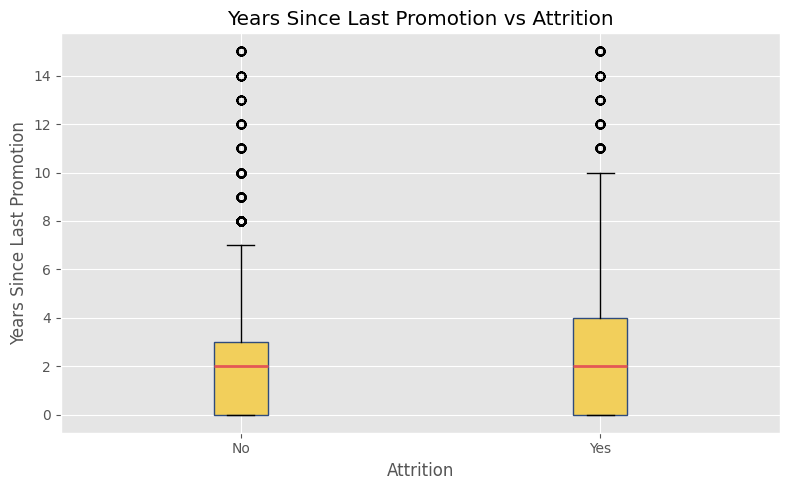

In [56]:
plt.figure(figsize=(8, 5))
promo_no = analysis_df.loc[analysis_df['attrition'] == 'No', 'years_since_last_promotion'].dropna()
promo_yes = analysis_df.loc[analysis_df['attrition'] == 'Yes', 'years_since_last_promotion'].dropna()
plt.boxplot([promo_no, promo_yes], labels=['No', 'Yes'], patch_artist=True, boxprops=dict(facecolor='#F2CF5B', color='#2F4B7C'), medianprops=dict(color='#E45756', linewidth=2))
plt.title('Years Since Last Promotion vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years Since Last Promotion')
plt.tight_layout()
plt.show()

### Insight

A larger promotion gap should correspond to higher churn risk because long delays in promotion often reduce retention.

C:\Users\MuvvaAkshaya\AppData\Local\Temp\ipykernel_3344\2360392364.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([performance_no, performance_yes], labels=['No', 'Yes'], patch_artist=True, boxprops=dict(facecolor='#B279A2', color='#2F4B7C'), medianprops=dict(color='#E45756', linewidth=2))


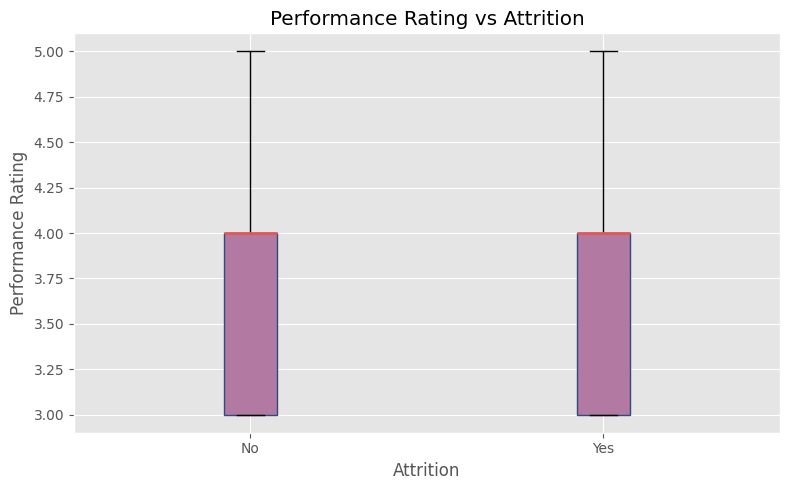

In [57]:
plt.figure(figsize=(8, 5))
performance_no = analysis_df.loc[analysis_df['attrition'] == 'No', 'performance_rating'].dropna()
performance_yes = analysis_df.loc[analysis_df['attrition'] == 'Yes', 'performance_rating'].dropna()
plt.boxplot([performance_no, performance_yes], labels=['No', 'Yes'], patch_artist=True, boxprops=dict(facecolor='#B279A2', color='#2F4B7C'), medianprops=dict(color='#E45756', linewidth=2))
plt.title('Performance Rating vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Performance Rating')
plt.tight_layout()
plt.show()

C:\Users\MuvvaAkshaya\AppData\Local\Temp\ipykernel_3344\3345196870.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([monthly_income_no, monthly_income_yes], labels=['No', 'Yes'], patch_artist=True, boxprops=dict(facecolor='#72B7B2', color='#2F4B7C'), medianprops=dict(color='#E45756', linewidth=2))


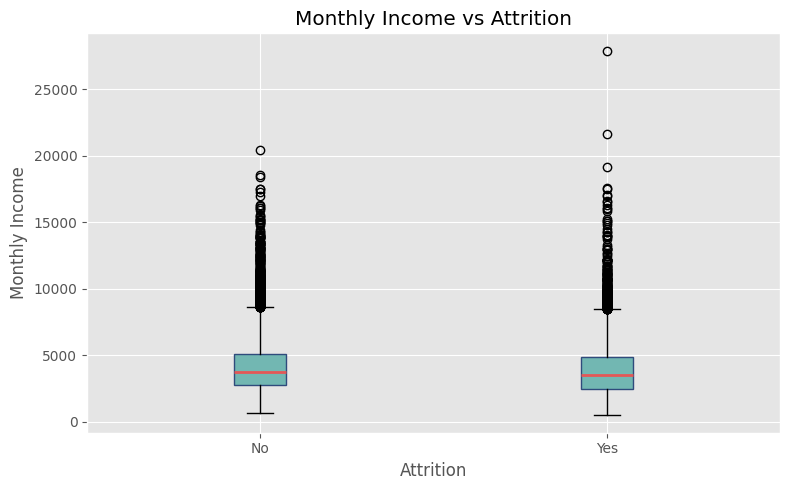

In [58]:
plt.figure(figsize=(8, 5))
monthly_income_no = analysis_df.loc[analysis_df['attrition'] == 'No', 'monthly_income'].dropna()
monthly_income_yes = analysis_df.loc[analysis_df['attrition'] == 'Yes', 'monthly_income'].dropna()
plt.boxplot([monthly_income_no, monthly_income_yes], labels=['No', 'Yes'], patch_artist=True, boxprops=dict(facecolor='#72B7B2', color='#2F4B7C'), medianprops=dict(color='#E45756', linewidth=2))
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.show()

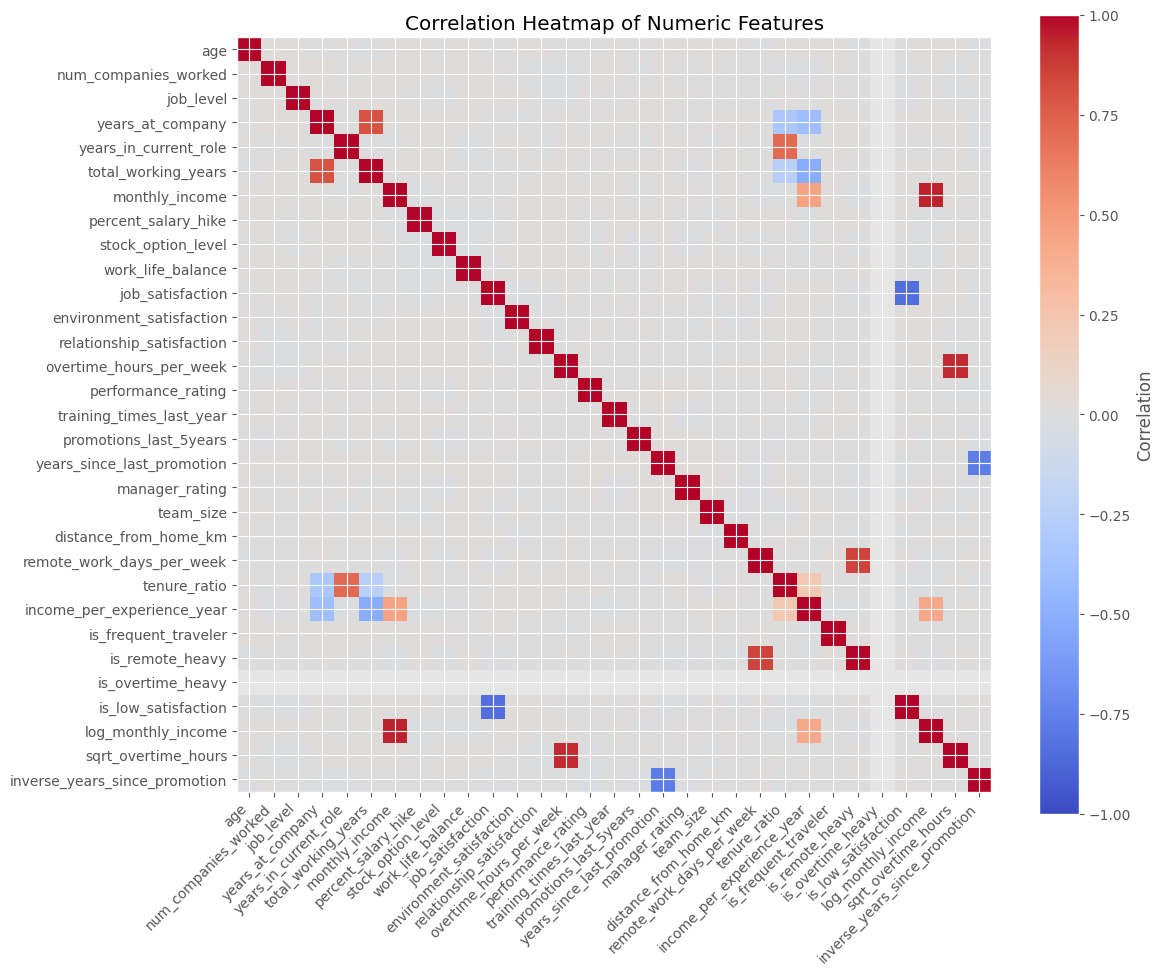

In [59]:
numeric_for_corr = analysis_df.select_dtypes(include=[np.number]).drop(columns=['employee_id'], errors='ignore')
corr = numeric_for_corr.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label='Correlation')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

### Insight

This plot helps confirm whether performance rating separates churn from non-churn strongly enough to justify more than mode fallback.

## 2.6 Outlier Handling

The boxplots show a few strong right tails in the continuous features. I will cap those extreme values with the IQR rule instead of dropping rows, so the dataset stays complete and the later charts are easier to read.

In [60]:
outlier_columns = ['monthly_income', 'overtime_hours_per_week', 'years_since_last_promotion', 'years_at_company', 'years_in_current_role', 'total_working_years', 'distance_from_home_km']

print('Outlier check using the IQR rule:')
for column in outlier_columns:
    if column not in analysis_df.columns:
        continue
    values = pd.to_numeric(analysis_df[column], errors='coerce')
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((values < lower_bound) | (values > upper_bound)).sum()
    print(column, 'outliers before capping:', int(outlier_count))
    analysis_df[column] = values.clip(lower=lower_bound, upper=upper_bound)

print('Outlier capping completed for the continuous fields above.')

Outlier check using the IQR rule:
monthly_income outliers before capping: 599
overtime_hours_per_week outliers before capping: 517
years_since_last_promotion outliers before capping: 352
years_at_company outliers before capping: 730
years_in_current_role outliers before capping: 638
total_working_years outliers before capping: 494
distance_from_home_km outliers before capping: 735
Outlier capping completed for the continuous fields above.


## 5. Summary

The notebook now follows a cleaner sequence: inspect the data, clean it, define the hypotheses, build the features needed for testing, run the tests, and then review the visuals one at a time. Performance rating and job satisfaction now use the same trial-and-fallback flow: if the data does not show a useful association, the missing values are filled with the mode and the notebook does not force a more complex path.